In [1]:
import pandas as pd
import numpy as np

In [ ]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
df=pd.read_csv("/content/airlines_delay.csv")

In [3]:
df.head(2)

,Flight,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class
0,2313.0,1296.0,141.0,DL,ATL,HOU,1,0
1,6948.0,360.0,146.0,OO,COS,ORD,4,0


In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.duplicated().sum()

np.int64(216618)

In [7]:
df.shape

(539382, 8)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539382 entries, 0 to 539381
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Flight       539382 non-null  float64
 1   Time         539382 non-null  float64
 2   Length       539382 non-null  float64
 3   Airline      539382 non-null  object 
 4   AirportFrom  539382 non-null  object 
 5   AirportTo    539382 non-null  object 
 6   DayOfWeek    539382 non-null  int64  
 7   Class        539382 non-null  int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 32.9+ MB


In [9]:

df.columns

Index(['Flight', 'Time', 'Length', 'Airline', 'AirportFrom', 'AirportTo',
       'DayOfWeek', 'Class'],
      dtype='object')

In [10]:
df["Flight"].nunique()

6585

In [11]:
df=df.drop(["Flight"],axis=1)

In [12]:

df

,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class
0,1296.0,141.0,DL,ATL,HOU,1,0
1,360.0,146.0,OO,COS,ORD,4,0
2,1170.0,143.0,B6,BOS,CLT,3,0
3,1410.0,344.0,US,OGG,PHX,6,0
4,692.0,98.0,FL,BMI,ATL,4,0
...,...,...,...,...,...,...,...
539377,530.0,72.0,OO,GEG,SEA,5,1
539378,560.0,115.0,WN,LAS,DEN,4,1
539379,827.0,74.0,EV,CAE,ATL,2,1
539380,715.0,65.0,WN,BWI,BUF,4,1


In [13]:
df["Weekend"]=np.where(df["DayOfWeek"]>5,1,0)

In [14]:
df["Weekend"]

,Weekend
0,0
1,0
2,0
3,1
4,0
...,...
539377,0
539378,0
539379,0
539380,0


In [15]:
df["Route"] = df["AirportFrom"] + "_" + df["AirportTo"]

In [16]:
airport_counts = df["AirportFrom"].value_counts()

df["BusyAirport"] = df["AirportFrom"].map(airport_counts)

In [17]:


delay_rate = df.groupby("AirportFrom")["Class"].mean()

df["AirportDelayRate"] = df["AirportFrom"].map(delay_rate)

In [18]:
df

,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class,Weekend,Route,BusyAirport,AirportDelayRate
0,1296.0,141.0,DL,ATL,HOU,1,0,0,ATL_HOU,34449,0.423844
1,360.0,146.0,OO,COS,ORD,4,0,0,COS_ORD,1031,0.358875
2,1170.0,143.0,B6,BOS,CLT,3,0,0,BOS_CLT,9439,0.394321
3,1410.0,344.0,US,OGG,PHX,6,0,1,OGG_PHX,1772,0.253950
4,692.0,98.0,FL,BMI,ATL,4,0,0,BMI_ATL,405,0.427160
...,...,...,...,...,...,...,...,...,...,...,...
539377,530.0,72.0,OO,GEG,SEA,5,1,0,GEG_SEA,1060,0.451887
539378,560.0,115.0,WN,LAS,DEN,4,1,0,LAS_DEN,11918,0.559993
539379,827.0,74.0,EV,CAE,ATL,2,1,0,CAE_ATL,683,0.355783
539380,715.0,65.0,WN,BWI,BUF,4,1,0,BWI_BUF,8565,0.573263


In [19]:

df["Class"].value_counts()

,count
Class,
0,299118
1,240264


In [20]:


df["AirportFrom"].value_counts().sort_values(ascending=False).head(10)

,count
AirportFrom,
ATL,34449
ORD,24822
DFW,22153
DEN,19843
LAX,16657
IAH,15821
PHX,15557
DTW,13136
LAS,11918


In [21]:

df["AirportTo"].value_counts().sort_values(ascending=False).head(10)

,count
AirportTo,
ATL,34440
ORD,24871
DFW,22153
DEN,19848
LAX,16656
IAH,15819
PHX,15558
DTW,13146
LAS,11918


In [22]:

df.groupby("AirportFrom")["Class"].mean().sort_values(ascending=False).head(10)

,Class
AirportFrom,
MDW,0.735182
DAL,0.715998
OAK,0.712926
HOU,0.667195
OTH,0.634409
FLO,0.611111
SMF,0.605879
GUM,0.600000
SJC,0.587131


In [23]:


df.groupby("AirportTo")["Class"].mean().sort_values(ascending=False).head(10)

,Class
AirportTo,
OAK,0.637133
RDD,0.633333
ONT,0.630983
MDW,0.626021
ISP,0.625990
STX,0.622222
SMF,0.615606
HOU,0.615524
BOI,0.612583


<h1>Handlig Time Column</h1>

In [24]:
df["Time"]=df["Time"].astype(int)

In [25]:

df["Time"].describe()

,Time
count,539382.000000
mean,802.728161
std,278.045546
min,10.000000
25%,565.000000
50%,795.000000
75%,1035.000000
max,1439.000000


In [26]:
df["Hour"] = df["Time"] // 100  ## hours

In [27]:

df["Minute"] = df["Time"] % 100  # Mintues

In [28]:
df[df["Time"] % 100 >= 60]

,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class,Weekend,Route,BusyAirport,AirportDelayRate,Hour,Minute
0,1296,141.0,DL,ATL,HOU,1,0,0,ATL_HOU,34449,0.423844,12,96
1,360,146.0,OO,COS,ORD,4,0,0,COS_ORD,1031,0.358875,3,60
2,1170,143.0,B6,BOS,CLT,3,0,0,BOS_CLT,9439,0.394321,11,70
4,692,98.0,FL,BMI,ATL,4,0,0,BMI_ATL,405,0.427160,6,92
5,580,60.0,WN,MSY,BHM,4,0,0,MSY_BHM,3400,0.402941,5,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...
539369,865,337.0,AS,HNL,SEA,6,1,1,HNL_SEA,4454,0.319488,8,65
539371,1170,86.0,XE,IAH,PNS,1,1,0,IAH_PNS,15821,0.484483,11,70
539375,480,287.0,CO,LAS,EWR,2,1,0,LAS_EWR,11918,0.559993,4,80
539378,560,115.0,WN,LAS,DEN,4,1,0,LAS_DEN,11918,0.559993,5,60


<h1>Length Analysis</h1>

In [29]:
df["Length"]=df["Length"].astype(int)

In [30]:
df.groupby("Length")["Class"].mean()

,Class
Length,
0,0.250000
23,1.000000
24,0.000000
25,0.454545
26,0.500000
...,...
560,0.791667
570,0.516129
610,1.000000


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

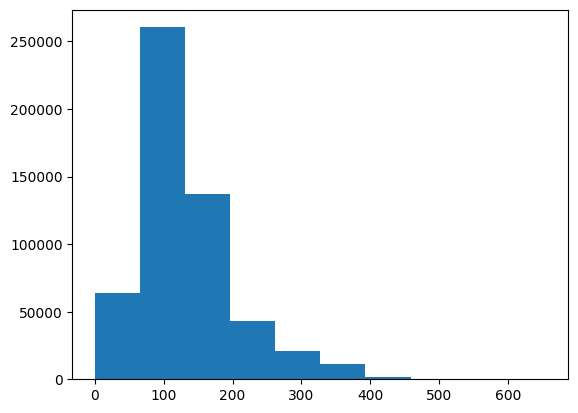

In [33]:
plt.hist(df["Length"])
plt.show()

<h1>Feature Engineering</h1>

In [34]:
df["RushHour"] = df["Hour"].apply(
    lambda x: 1 if 6 <= x <= 9 or 17 <= x <= 21 else 0
)

In [35]:
df["RushHour"]

,RushHour
0,0
1,0
2,0
3,0
4,1
...,...
539377,0
539378,0
539379,1
539380,1


In [36]:
df["NightFlight"] = df["Hour"].apply(
    lambda x: 1 if x >= 22 or x <= 5 else 0
)

In [37]:
df["NightFlight"]

,NightFlight
0,0
1,1
2,0
3,0
4,0
...,...
539377,1
539378,1
539379,0
539380,0


In [38]:
df["FlightType"] = df["Length"].apply(
    lambda x: "Short" if x < 120 else "Long"
)
df["FlightType"]

,FlightType
0,Long
1,Long
2,Long
3,Long
4,Short
...,...
539377,Short
539378,Short
539379,Short
539380,Short


In [39]:
df["LongFlight"] = df["Length"].apply(
    lambda x: 1 if x >= 120 else 0
)
df["LongFlight"]

,LongFlight
0,1
1,1
2,1
3,1
4,0
...,...
539377,0
539378,0
539379,0
539380,0


<h1 color="green">EDA OF DATA</h1>

In [40]:
df["Time"].sort_values().tail(20)

,Time
495571,1439
12241,1439
477032,1439
495592,1439
477648,1439
11609,1439
191761,1439
67722,1439
62842,1439
68881,1439


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Class'>

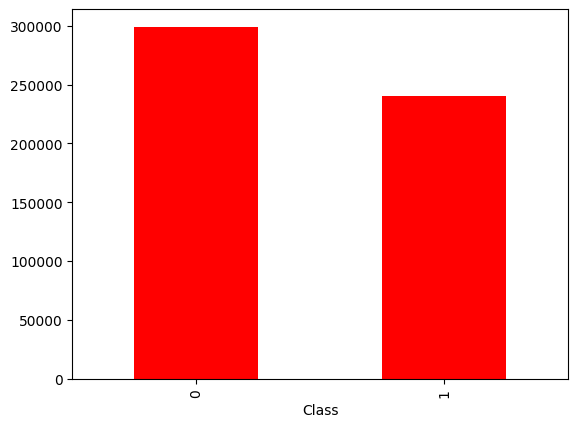

In [42]:
df["Class"].value_counts().plot(kind="bar",color="red")

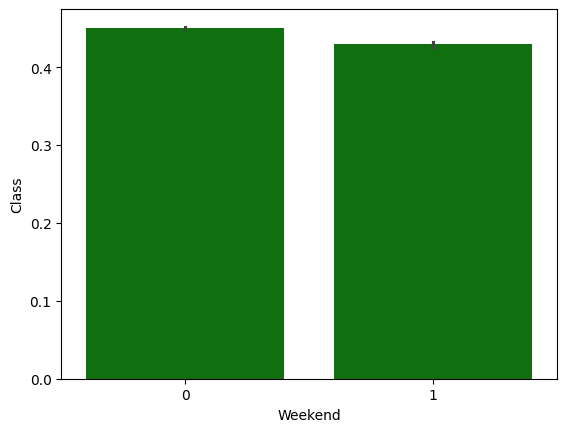

In [43]:
sns.barplot(x="Weekend",y='Class',data=df,color="green")
plt.show()

<p>
    Week day have flight dealys than weekend may be due to that people are busy in daily work choas
</p>

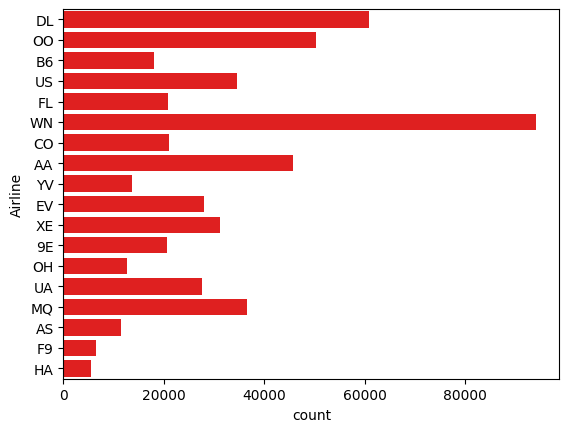

In [44]:
## airpline wise flight delays
sns.countplot(df['Airline'],color='red')
plt.show()

<Axes: ylabel='count'>

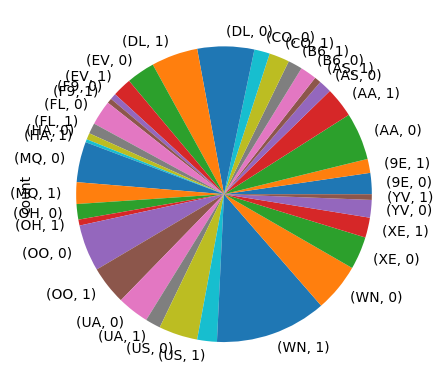

In [45]:
df.groupby("Airline")["Class"].value_counts().plot(kind="pie")

<h4>Top Dealy Airplot</h4>

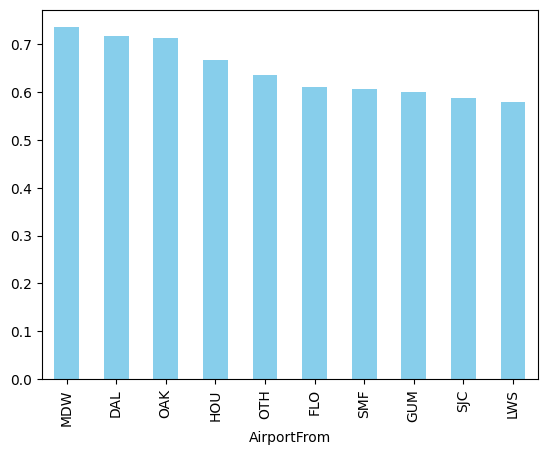

In [46]:
df.groupby("AirportFrom")["Class"].mean().sort_values(ascending=False).head(10).plot(kind="bar",color="skyblue")

plt.show()

<h2>Route by Analysis</h2>

<Axes: xlabel='Route'>

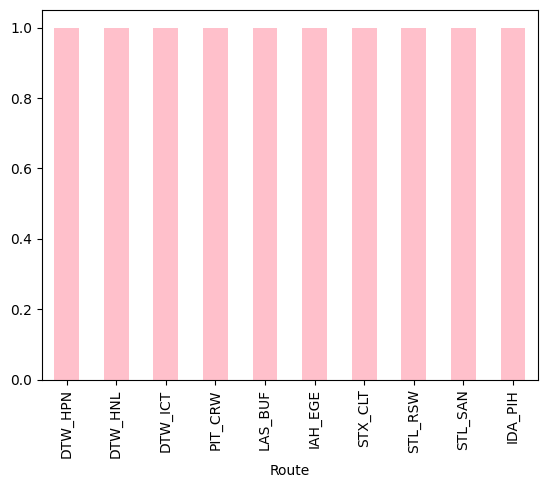

In [ ]:
df.groupby("Route")["Class"].mean().sort_values(ascending=False).head(10).plot(kind="bar",color="pink")

<Axes: xlabel='Hour'>

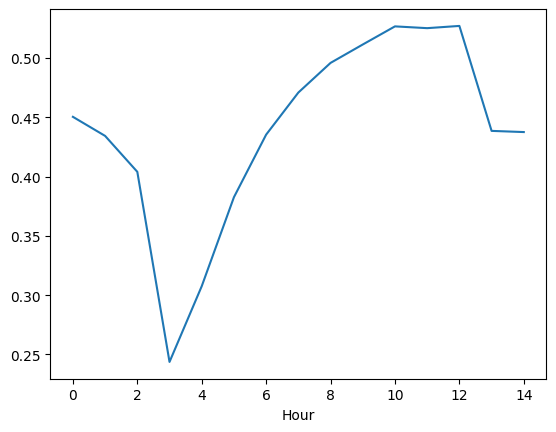

In [ ]:
df.groupby("Hour")["Class"].mean().plot(kind="line")

<Axes: xlabel='Minute'>

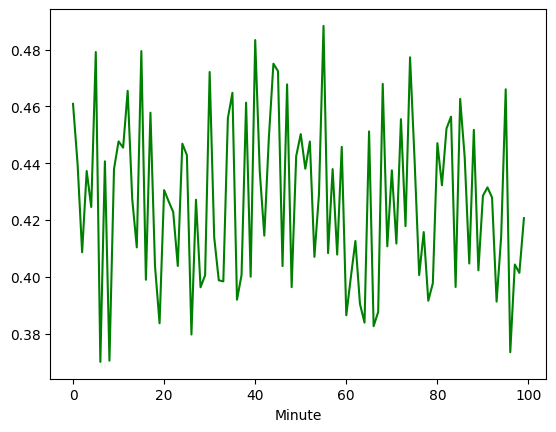

In [ ]:
df.groupby("Minute")["Class"].mean().plot(kind="line",color="green")

In [ ]:
df

,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class,Weekend,Route,BusyAirport,AirportDelayRate,Hour,Minute,RushHour,NightFlight,FlightType,LongFlight
0,1296,141,DL,ATL,HOU,1,0,0,ATL_HOU,34449,0.423844,12,96,0,0,Long,1
1,360,146,OO,COS,ORD,4,0,0,COS_ORD,1031,0.358875,3,60,0,1,Long,1
2,1170,143,B6,BOS,CLT,3,0,0,BOS_CLT,9439,0.394321,11,70,0,0,Long,1
3,1410,344,US,OGG,PHX,6,0,1,OGG_PHX,1772,0.253950,14,10,0,0,Long,1
4,692,98,FL,BMI,ATL,4,0,0,BMI_ATL,405,0.427160,6,92,1,0,Short,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539377,530,72,OO,GEG,SEA,5,1,0,GEG_SEA,1060,0.451887,5,30,0,1,Short,0
539378,560,115,WN,LAS,DEN,4,1,0,LAS_DEN,11918,0.559993,5,60,0,1,Short,0
539379,827,74,EV,CAE,ATL,2,1,0,CAE_ATL,683,0.355783,8,27,1,0,Short,0
539380,715,65,WN,BWI,BUF,4,1,0,BWI_BUF,8565,0.573263,7,15,1,0,Short,0


<Axes: xlabel='FlightType,Class'>

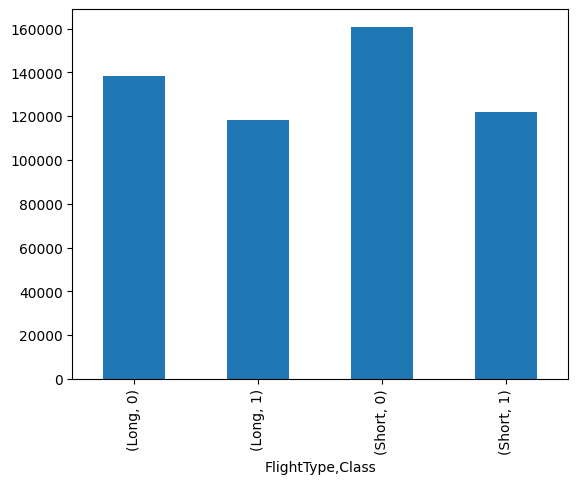

In [ ]:
df.groupby("FlightType")["Class"].value_counts().plot(kind="bar")

In [ ]:
df.columns

Index(['Time', 'Length', 'Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek',
       'Class', 'Weekend', 'Route', 'BusyAirport', 'AirportDelayRate', 'Hour',
       'Minute', 'RushHour', 'NightFlight', 'FlightType', 'LongFlight'],
      dtype='object')

<Axes: xlabel='LongFlight'>

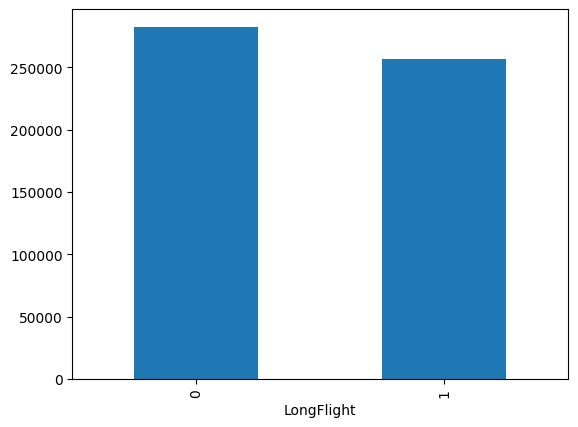

In [ ]:
df['LongFlight'].value_counts().plot(kind="bar")

<Axes: xlabel='LongFlight'>

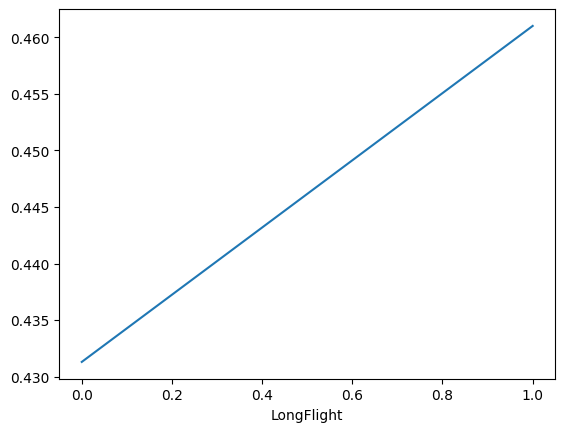

In [ ]:
df.groupby('LongFlight')["Class"].mean().plot(kind="line")

<h1>Model Training Part</h1>

In [ ]:
df.columns

Index(['Time', 'Length', 'Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek',
       'Class', 'Hour', 'Minute', 'RushHour', 'NightFlight', 'FlightType',
       'LongFlight'],
      dtype='object')

In [47]:
X = df[[
    "Airline",
    "AirportFrom",
    "AirportTo",
    "Hour",
    "Length",
    "RushHour",
    "NightFlight",
    "Weekend",
    "BusyAirport",
    "AirportDelayRate"
]]
X = pd.get_dummies(X,
                   columns=["Airline", "AirportFrom", "AirportTo"],
                   drop_first=True)

In [48]:
y=df["Class"]

In [ ]:
X

,Hour,Length,RushHour,NightFlight,Weekend,BusyAirport,AirportDelayRate,Airline_AA,Airline_AS,Airline_B6,...,Route_XNA_IAH,Route_XNA_LGA,Route_XNA_MEM,Route_XNA_MSP,Route_XNA_ORD,Route_YAK_CDV,Route_YAK_JNU,Route_YUM_IPL,Route_YUM_LAX,Route_YUM_PHX
0,12,141,0,0,0,34449,0.423844,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,3,146,0,1,0,1031,0.358875,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,11,143,0,0,0,9439,0.394321,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,14,344,0,0,1,1772,0.253950,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,6,98,1,0,0,405,0.427160,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539377,5,72,0,1,0,1060,0.451887,False,False,False,...,False,False,False,False,False,False,False,False,False,False
539378,5,115,0,1,0,11918,0.559993,False,False,False,...,False,False,False,False,False,False,False,False,False,False
539379,8,74,1,0,0,683,0.355783,False,False,False,...,False,False,False,False,False,False,False,False,False,False
539380,7,65,1,0,0,8565,0.573263,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [50]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

<h1>Random Forest</h1>

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_



y_pred = best_rf.predict(X_test)


print("Best Parameters:")
print(grid_search.best_params_)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

KeyboardInterrupt: 

<h1>Decision Tree</h1>

In [61]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42,class_weight="balanced",max_depth=20,min_samples_split=30)
dt.fit(X_train, y_train)
y_p=dt.predict(X_test)
print(accuracy_score(y_test,y_p))

0.6517422620206346


In [63]:
print("\nClassification Report:")
print(classification_report(y_test, y_p))


Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.71      0.69     59714
           1       0.62      0.58      0.60     48163

    accuracy                           0.65    107877
   macro avg       0.65      0.64      0.65    107877
weighted avg       0.65      0.65      0.65    107877



<h1>XGBoost</h1>

In [53]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)
y_p=xgb.predict(X_test)


In [54]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_p)

0.6579437692928057

In [64]:
print("\nClassification Report:")
print(classification_report(y_test, y_p))


Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.71      0.69     59714
           1       0.62      0.58      0.60     48163

    accuracy                           0.65    107877
   macro avg       0.65      0.64      0.65    107877
weighted avg       0.65      0.65      0.65    107877

